<a href="https://colab.research.google.com/github/akshatsharma-x/ML/blob/main/ML_LAB_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================================
# METHOD 1: Upload Files Directly from Computer
# ============================================================================

print("METHOD 1: Upload Files from Your Computer")
print("=" * 60)

from google.colab import files
import io

# Upload a single file
print("\n1. Upload a single file:")
print("-" * 40)
uploaded = files.upload()

# Get the filename
for filename in uploaded.keys():
    print(f'✓ Uploaded file: {filename}')
    print(f'  Size: {len(uploaded[filename])} bytes')

# ============================================================================
# METHOD 2: Upload Multiple Files
# ============================================================================

print("\n\nMETHOD 2: Upload Multiple Files at Once")
print("=" * 60)

from google.colab import files

# Upload multiple files
uploaded_files = files.upload()

# Process each uploaded file
for filename, file_content in uploaded_files.items():
    print(f'✓ Uploaded: {filename} ({len(file_content)} bytes)')

METHOD 1: Upload Files from Your Computer

1. Upload a single file:
----------------------------------------


Saving breast+cancer+wisconsin+diagnostic.zip to breast+cancer+wisconsin+diagnostic.zip
✓ Uploaded file: breast+cancer+wisconsin+diagnostic.zip
  Size: 51284 bytes


METHOD 2: Upload Multiple Files at Once


Saving breast+cancer+wisconsin+diagnostic.zip to breast+cancer+wisconsin+diagnostic (1).zip
✓ Uploaded: breast+cancer+wisconsin+diagnostic (1).zip (51284 bytes)


ML LAB-09: SUPERVISED LEARNING - ARTIFICIAL NEURAL NETWORKS (ANN)

EXPERIMENT-1: SHALLOW NEURAL NETWORK CLASSIFICATION
--------------------------------------------------------------------------------

1. Loading Breast Cancer Wisconsin Dataset...
Dataset shape: (569, 31)
Features: 30
Classes: ['malignant' 'benign']
Class distribution:
  - Malignant (0): 212
  - Benign (1): 357

Training set size: 455
Testing set size: 114

1a. Scaling features using StandardScaler...
    (IMPORTANT: Neural Networks are highly sensitive to unscaled data)
✓ Features scaled successfully

2. Training Shallow Neural Network Classifier...
✓ Model trained successfully
Architecture: (15,)
Activation function: relu
Iterations to converge: 339

3. Predicting class labels...
✓ Predictions completed

4. Model Evaluation:
----------------------------------------
Training Accuracy: 0.9934 (99.34%)
Testing Accuracy: 0.9561 (95.61%)

Confusion Matrix:
[[41  1]
 [ 4 68]]
  TN: 41, FP: 1
  FN: 4, TP: 68

Classification 

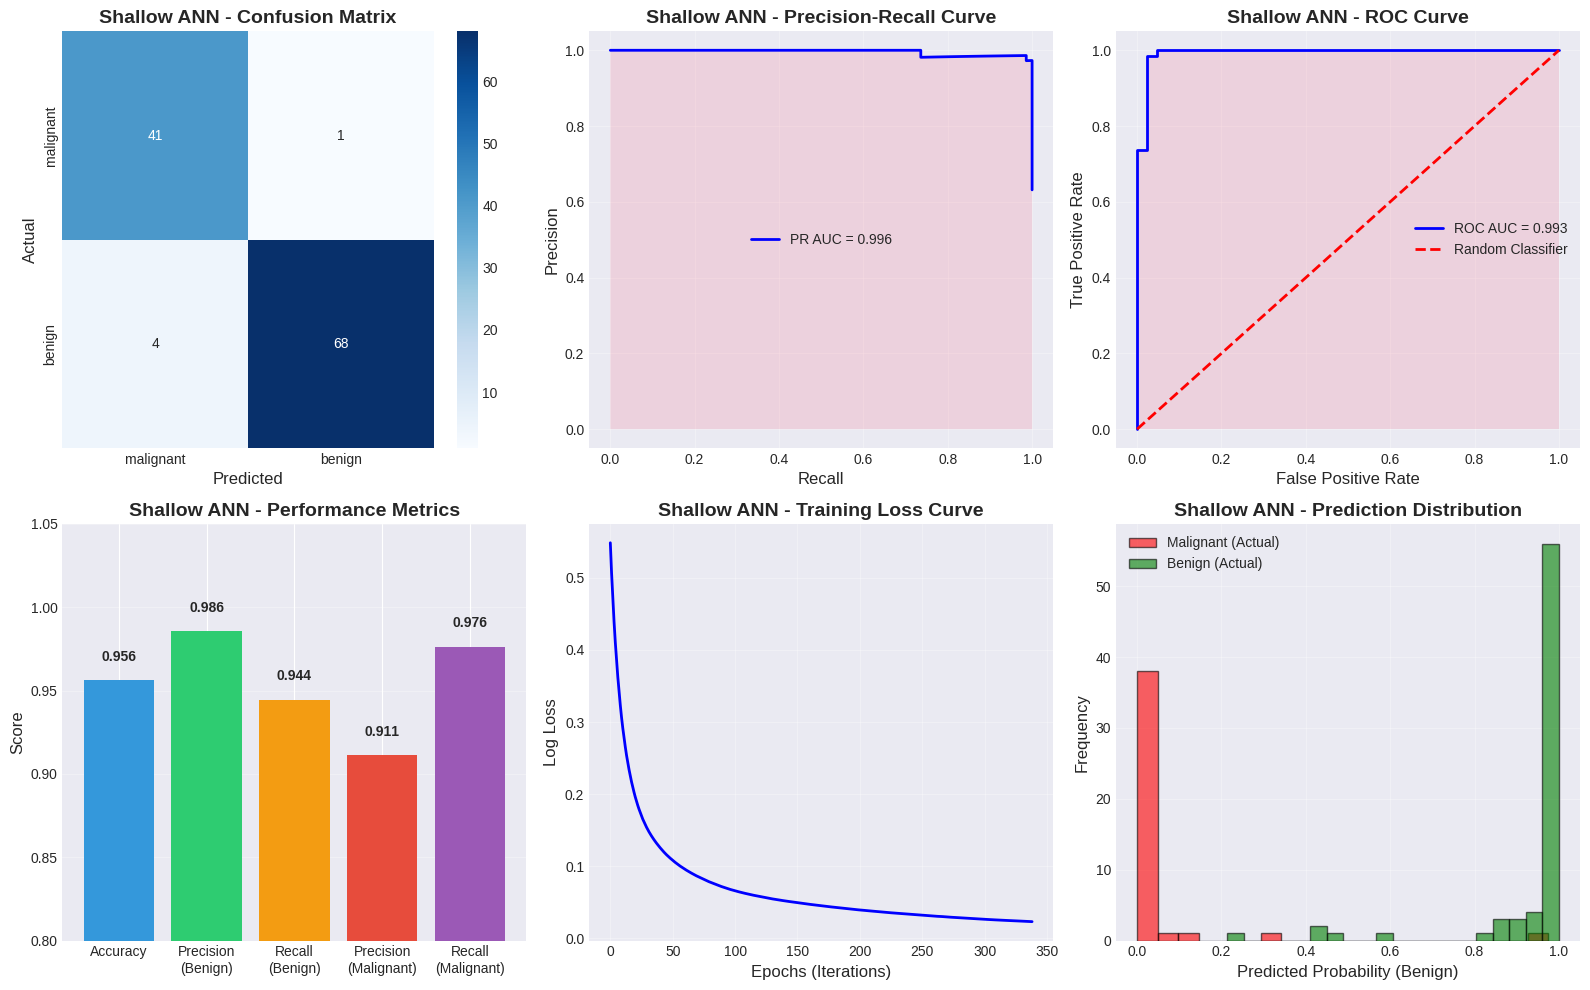

Generating Deep ANN Visualizations...
Displaying Deep ANN Visualizations... (Close the window to continue)


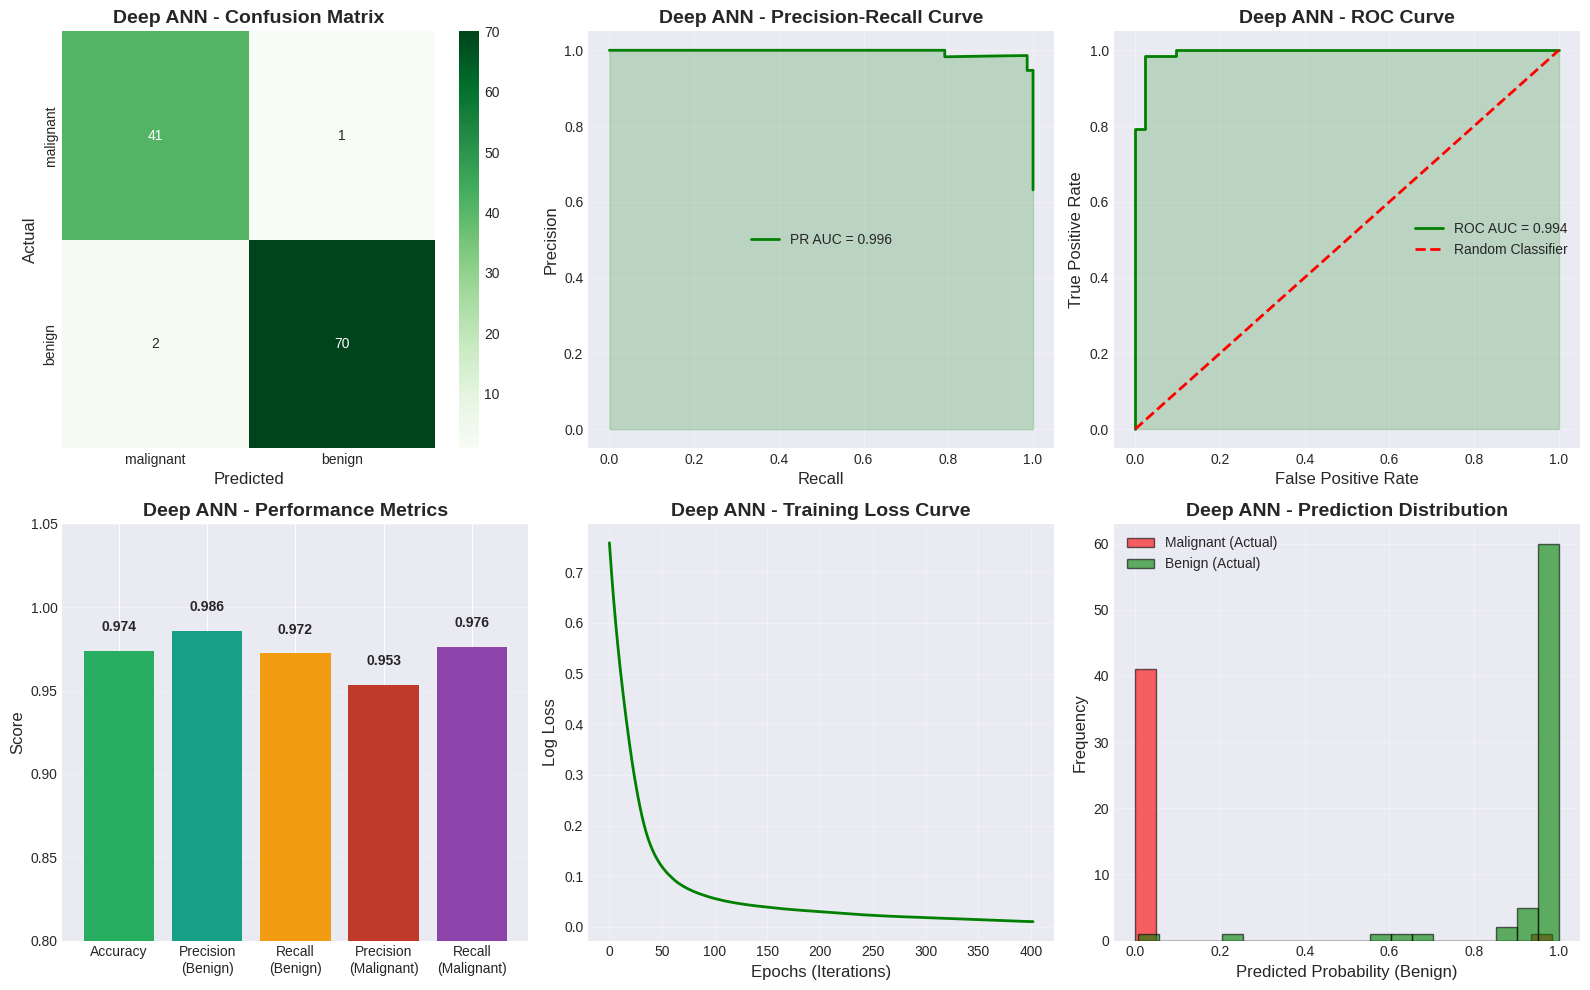


EXPERIMENT-3: ARCHITECTURE COMPARISON
--------------------------------------------------------------------------------

1. ACCURACY COMPARISON:
----------------------------------------
Shallow ANN (1 Hidden Layer):
  Training Accuracy: 0.9934 (99.34%)
  Testing Accuracy:  0.9561 (95.61%)

Deep ANN (2 Hidden Layers):
  Training Accuracy: 0.9978 (99.78%)
  Testing Accuracy:  0.9737 (97.37%)

2. RECALL FOR MALIGNANT CASES:
----------------------------------------
Shallow ANN: 0.9762 (97.62%)
Deep ANN:    0.9762 (97.62%)

3. CONVERGENCE ANALYSIS:
----------------------------------------
Shallow ANN iterations: 339
Deep ANN iterations:    403

Generating Architecture Comparison Visualizations...
Displaying Architecture Comparison Visualizations... (Close the window to continue)


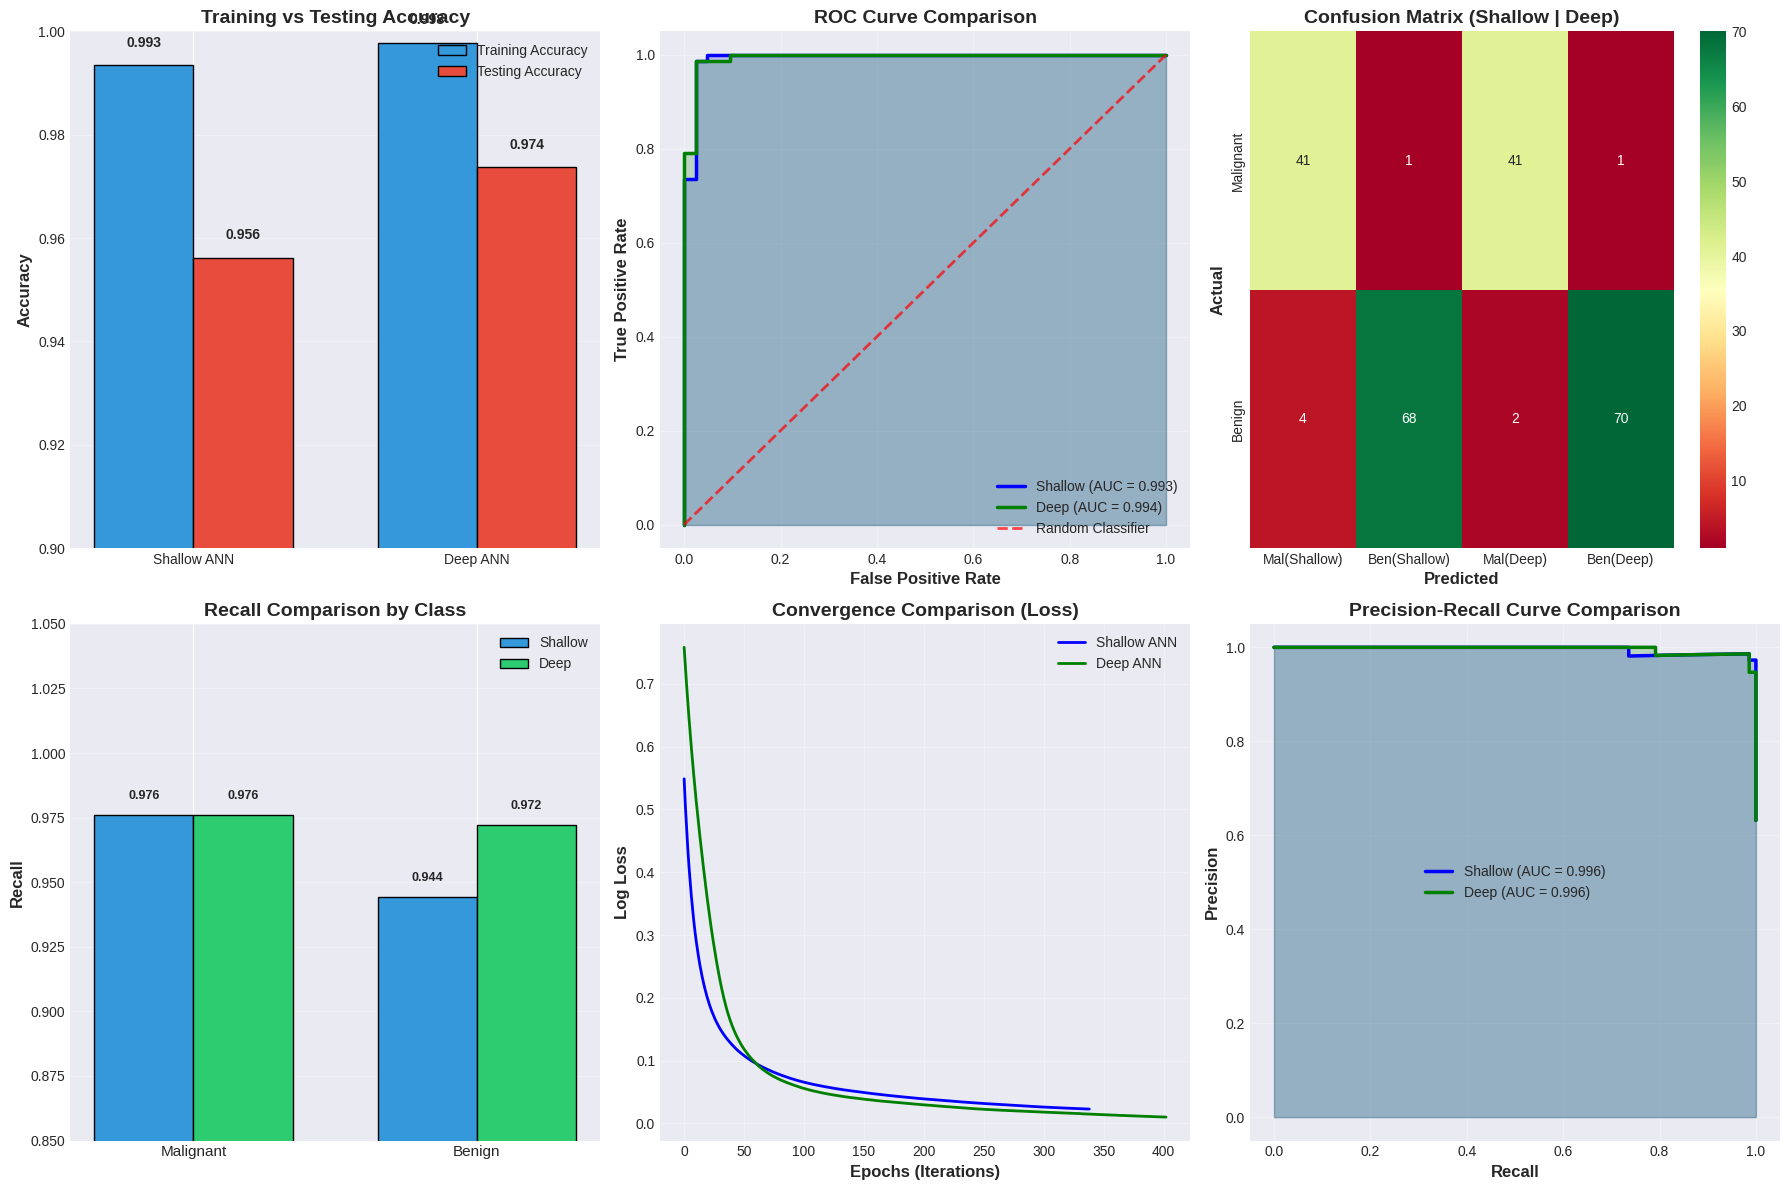


SUMMARY AND ANALYSIS

1. Which ANN architecture achieved higher accuracy?
  → Deep ANN achieved higher testing accuracy: 0.9737
    (vs Shallow: 0.9561)

2. Which model showed better recall for malignant cases?
  → Shallow ANN showed better recall: 0.9762
    (vs Deep: 0.9762)

3. How did the complexity affect training (Convergence)?
  → The Deep network required 403 iterations to converge,
    while the Shallow network took 339 iterations.
  Reason: Additional hidden layers create a more complex loss landscape,
  meaning backpropagation takes more epochs to find the optimal weights.

4. Why was StandardScaler crucial for this experiment?
  → Artificial Neural Networks use gradient descent for optimization.
  If features have vastly different scales (e.g., mean radius vs. area),
  the loss function will be highly elongated, causing the gradient
  descent to oscillate inefficiently or fail to converge altogether.
  Scaling normalizes the gradients, allowing for faster and more stable l

In [2]:
"""
ML LAB-09: SUPERVISED LEARNING
Artificial Neural Networks (ANN) Classification

This script implements complete experiments for building, evaluating, and comparing
Shallow and Deep Multi-Layer Perceptron (MLP) models on the Breast Cancer Wisconsin dataset.

Author: ML Lab
Date: 2026
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, auc, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("ML LAB-09: SUPERVISED LEARNING - ARTIFICIAL NEURAL NETWORKS (ANN)")
print("=" * 80)
print()

# ============================================================================
# EXPERIMENT-1: SHALLOW NEURAL NETWORK (1 Hidden Layer)
# ============================================================================
print("EXPERIMENT-1: SHALLOW NEURAL NETWORK CLASSIFICATION")
print("-" * 80)

# 1) Load the dataset and split
print("\n1. Loading Breast Cancer Wisconsin Dataset...")
data = load_breast_cancer()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(f"Dataset shape: {df.shape}")
print(f"Features: {len(data.feature_names)}")
print(f"Classes: {data.target_names}")
print(f"Class distribution:")
print(f"  - Malignant (0): {sum(y==0)}")
print(f"  - Benign (1): {sum(y==1)}")

# Split into training and testing sets (80-20 split standard for NNs)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# CRITICAL: Feature Scaling for Neural Networks
print("\n1a. Scaling features using StandardScaler...")
print("    (IMPORTANT: Neural Networks are highly sensitive to unscaled data)")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Features scaled successfully")

# 2) Train Shallow Neural Network classifier
print("\n2. Training Shallow Neural Network Classifier...")
# 1 hidden layer with 15 neurons
ann_shallow = MLPClassifier(hidden_layer_sizes=(15,), max_iter=1000, random_state=42)
ann_shallow.fit(X_train_scaled, y_train)
print("✓ Model trained successfully")
print(f"Architecture: {ann_shallow.hidden_layer_sizes}")
print(f"Activation function: {ann_shallow.activation}")
print(f"Iterations to converge: {ann_shallow.n_iter_}")

# 3) Predict class labels
print("\n3. Predicting class labels...")
y_pred_shallow = ann_shallow.predict(X_test_scaled)
y_pred_proba_shallow = ann_shallow.predict_proba(X_test_scaled)[:, 1]
print("✓ Predictions completed")

# 4) Evaluate the model
print("\n4. Model Evaluation:")
print("-" * 40)

# Accuracy
shallow_train_acc = accuracy_score(y_train, ann_shallow.predict(X_train_scaled))
shallow_test_acc = accuracy_score(y_test, y_pred_shallow)
print(f"Training Accuracy: {shallow_train_acc:.4f} ({shallow_train_acc*100:.2f}%)")
print(f"Testing Accuracy: {shallow_test_acc:.4f} ({shallow_test_acc*100:.2f}%)")

# Confusion Matrix
print("\nConfusion Matrix:")
cm_shallow = confusion_matrix(y_test, y_pred_shallow)
print(cm_shallow)
print(f"  TN: {cm_shallow[0,0]}, FP: {cm_shallow[0,1]}")
print(f"  FN: {cm_shallow[1,0]}, TP: {cm_shallow[1,1]}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_shallow, target_names=data.target_names))

# Precision-Recall Curve
precision_shallow, recall_shallow, _ = precision_recall_curve(y_test, y_pred_proba_shallow)
pr_auc_shallow = auc(recall_shallow, precision_shallow)
print(f"Precision-Recall AUC: {pr_auc_shallow:.4f}")

# ROC Curve
fpr_shallow, tpr_shallow, _ = roc_curve(y_test, y_pred_proba_shallow)
roc_auc_shallow = auc(fpr_shallow, tpr_shallow)
print(f"ROC AUC: {roc_auc_shallow:.4f}")

print("\n" + "=" * 80)

# ============================================================================
# EXPERIMENT-2: DEEP NEURAL NETWORK (Multiple Hidden Layers)
# ============================================================================
print("\nEXPERIMENT-2: DEEP NEURAL NETWORK CLASSIFICATION")
print("-" * 80)

print("\n1. Using same train/test split from Experiment 1")
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# 2) Train Deep Neural Network classifier
print("\n2. Training Deep Neural Network Classifier...")
# 2 hidden layers: 10 neurons, then 8 neurons
ann_deep = MLPClassifier(hidden_layer_sizes=(10, 8), max_iter=1000, random_state=42)
ann_deep.fit(X_train_scaled, y_train)
print("✓ Model trained successfully")
print(f"Architecture: {ann_deep.hidden_layer_sizes}")
print(f"Activation function: {ann_deep.activation}")
print(f"Iterations to converge: {ann_deep.n_iter_}")

# 3) Predict class labels
print("\n3. Predicting class labels...")
y_pred_deep = ann_deep.predict(X_test_scaled)
y_pred_proba_deep = ann_deep.predict_proba(X_test_scaled)[:, 1]
print("✓ Predictions completed")

# 4) Evaluate the model
print("\n4. Model Evaluation:")
print("-" * 40)

# Accuracy
deep_train_acc = accuracy_score(y_train, ann_deep.predict(X_train_scaled))
deep_test_acc = accuracy_score(y_test, y_pred_deep)
print(f"Training Accuracy: {deep_train_acc:.4f} ({deep_train_acc*100:.2f}%)")
print(f"Testing Accuracy: {deep_test_acc:.4f} ({deep_test_acc*100:.2f}%)")

# Confusion Matrix
print("\nConfusion Matrix:")
cm_deep = confusion_matrix(y_test, y_pred_deep)
print(cm_deep)
print(f"  TN: {cm_deep[0,0]}, FP: {cm_deep[0,1]}")
print(f"  FN: {cm_deep[1,0]}, TP: {cm_deep[1,1]}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_deep, target_names=data.target_names))

# Precision-Recall & ROC Curve AUCs
precision_deep, recall_deep, _ = precision_recall_curve(y_test, y_pred_proba_deep)
pr_auc_deep = auc(recall_deep, precision_deep)
fpr_deep, tpr_deep, _ = roc_curve(y_test, y_pred_proba_deep)
roc_auc_deep = auc(fpr_deep, tpr_deep)
print(f"Precision-Recall AUC: {pr_auc_deep:.4f}")
print(f"ROC AUC: {roc_auc_deep:.4f}")

print("\n" + "=" * 80)

# ============================================================================
# VISUALIZATIONS FOR SHALLOW ANN
# ============================================================================
print("\nGenerating Shallow ANN Visualizations...")

fig1 = plt.figure(figsize=(16, 10))
fig1.canvas.manager.set_window_title('Shallow ANN Visualizations')

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Shallow ANN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

# 2. Precision-Recall Curve
ax2 = plt.subplot(2, 3, 2)
plt.plot(recall_shallow, precision_shallow, 'b-', linewidth=2, label=f'PR AUC = {pr_auc_shallow:.3f}')
plt.fill_between(recall_shallow, precision_shallow, alpha=0.2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Shallow ANN - Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# 3. ROC Curve
ax3 = plt.subplot(2, 3, 3)
plt.plot(fpr_shallow, tpr_shallow, 'b-', linewidth=2, label=f'ROC AUC = {roc_auc_shallow:.3f}')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
plt.fill_between(fpr_shallow, tpr_shallow, alpha=0.2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Shallow ANN - ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# 4. Performance Metrics
ax4 = plt.subplot(2, 3, 4)
metrics = ['Accuracy', 'Precision\n(Benign)', 'Recall\n(Benign)',
           'Precision\n(Malignant)', 'Recall\n(Malignant)']
values = [
    shallow_test_acc,
    precision_score(y_test, y_pred_shallow, pos_label=1),
    recall_score(y_test, y_pred_shallow, pos_label=1),
    precision_score(y_test, y_pred_shallow, pos_label=0),
    recall_score(y_test, y_pred_shallow, pos_label=0)
]
bars = plt.bar(metrics, values, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'])
plt.ylim(0.8, 1.05)
plt.ylabel('Score', fontsize=12)
plt.title('Shallow ANN - Performance Metrics', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 5. Training Loss Curve
ax5 = plt.subplot(2, 3, 5)
plt.plot(ann_shallow.loss_curve_, 'b-', linewidth=2)
plt.xlabel('Epochs (Iterations)', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Shallow ANN - Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 6. Prediction Distribution
ax6 = plt.subplot(2, 3, 6)
plt.hist(y_pred_proba_shallow[y_test==0], bins=20, alpha=0.6,
         label='Malignant (Actual)', color='red', edgecolor='black')
plt.hist(y_pred_proba_shallow[y_test==1], bins=20, alpha=0.6,
         label='Benign (Actual)', color='green', edgecolor='black')
plt.xlabel('Predicted Probability (Benign)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Shallow ANN - Prediction Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
print("Displaying Shallow ANN Visualizations... (Close the window to continue)")
plt.show()

# ============================================================================
# VISUALIZATIONS FOR DEEP ANN
# ============================================================================
print("Generating Deep ANN Visualizations...")

fig2 = plt.figure(figsize=(16, 10))
fig2.canvas.manager.set_window_title('Deep ANN Visualizations')

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Deep ANN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

# 2. Precision-Recall Curve
ax2 = plt.subplot(2, 3, 2)
plt.plot(recall_deep, precision_deep, 'g-', linewidth=2, label=f'PR AUC = {pr_auc_deep:.3f}')
plt.fill_between(recall_deep, precision_deep, alpha=0.2, color='green')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Deep ANN - Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# 3. ROC Curve
ax3 = plt.subplot(2, 3, 3)
plt.plot(fpr_deep, tpr_deep, 'g-', linewidth=2, label=f'ROC AUC = {roc_auc_deep:.3f}')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
plt.fill_between(fpr_deep, tpr_deep, alpha=0.2, color='green')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Deep ANN - ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# 4. Performance Metrics
ax4 = plt.subplot(2, 3, 4)
values = [
    deep_test_acc,
    precision_score(y_test, y_pred_deep, pos_label=1),
    recall_score(y_test, y_pred_deep, pos_label=1),
    precision_score(y_test, y_pred_deep, pos_label=0),
    recall_score(y_test, y_pred_deep, pos_label=0)
]
bars = plt.bar(metrics, values, color=['#27ae60', '#16a085', '#f39c12', '#c0392b', '#8e44ad'])
plt.ylim(0.8, 1.05)
plt.ylabel('Score', fontsize=12)
plt.title('Deep ANN - Performance Metrics', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 5. Training Loss Curve
ax5 = plt.subplot(2, 3, 5)
plt.plot(ann_deep.loss_curve_, 'g-', linewidth=2)
plt.xlabel('Epochs (Iterations)', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Deep ANN - Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 6. Prediction Distribution
ax6 = plt.subplot(2, 3, 6)
plt.hist(y_pred_proba_deep[y_test==0], bins=20, alpha=0.6,
         label='Malignant (Actual)', color='red', edgecolor='black')
plt.hist(y_pred_proba_deep[y_test==1], bins=20, alpha=0.6,
         label='Benign (Actual)', color='green', edgecolor='black')
plt.xlabel('Predicted Probability (Benign)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Deep ANN - Prediction Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
print("Displaying Deep ANN Visualizations... (Close the window to continue)")
plt.show()

# ============================================================================
# EXPERIMENT-3: MODEL COMPARISON
# ============================================================================
print("\n" + "=" * 80)
print("EXPERIMENT-3: ARCHITECTURE COMPARISON")
print("-" * 80)

# Calculate comparison metrics
shallow_recall_malignant = recall_score(y_test, y_pred_shallow, pos_label=0)
deep_recall_malignant = recall_score(y_test, y_pred_deep, pos_label=0)

print("\n1. ACCURACY COMPARISON:")
print("-" * 40)
print(f"Shallow ANN (1 Hidden Layer):")
print(f"  Training Accuracy: {shallow_train_acc:.4f} ({shallow_train_acc*100:.2f}%)")
print(f"  Testing Accuracy:  {shallow_test_acc:.4f} ({shallow_test_acc*100:.2f}%)")
print(f"\nDeep ANN (2 Hidden Layers):")
print(f"  Training Accuracy: {deep_train_acc:.4f} ({deep_train_acc*100:.2f}%)")
print(f"  Testing Accuracy:  {deep_test_acc:.4f} ({deep_test_acc*100:.2f}%)")

print("\n2. RECALL FOR MALIGNANT CASES:")
print("-" * 40)
print(f"Shallow ANN: {shallow_recall_malignant:.4f} ({shallow_recall_malignant*100:.2f}%)")
print(f"Deep ANN:    {deep_recall_malignant:.4f} ({deep_recall_malignant*100:.2f}%)")

print("\n3. CONVERGENCE ANALYSIS:")
print("-" * 40)
print(f"Shallow ANN iterations: {ann_shallow.n_iter_}")
print(f"Deep ANN iterations:    {ann_deep.n_iter_}")

# ============================================================================
# COMPARISON VISUALIZATIONS
# ============================================================================
print("\nGenerating Architecture Comparison Visualizations...")

fig3 = plt.figure(figsize=(18, 12))
fig3.canvas.manager.set_window_title('Architecture Comparison Visualizations')

# 1. Training vs Testing Accuracy
ax1 = plt.subplot(2, 3, 1)
models = ['Shallow ANN', 'Deep ANN']
train_accs = [shallow_train_acc, deep_train_acc]
test_accs = [shallow_test_acc, deep_test_acc]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, train_accs, width, label='Training Accuracy',
                color='#3498db', edgecolor='black')
bars2 = ax1.bar(x + width/2, test_accs, width, label='Testing Accuracy',
                color='#e74c3c', edgecolor='black')

ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Training vs Testing Accuracy', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(fontsize=10)
ax1.set_ylim(0.90, 1.0)
ax1.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.003,
                 f'{height:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# 2. ROC Curve Comparison
ax2 = plt.subplot(2, 3, 2)
ax2.plot(fpr_shallow, tpr_shallow, 'b-', linewidth=2.5,
         label=f'Shallow (AUC = {roc_auc_shallow:.3f})')
ax2.plot(fpr_deep, tpr_deep, 'g-', linewidth=2.5,
         label=f'Deep (AUC = {roc_auc_deep:.3f})')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier', alpha=0.7)
ax2.fill_between(fpr_shallow, tpr_shallow, alpha=0.2, color='blue')
ax2.fill_between(fpr_deep, tpr_deep, alpha=0.2, color='green')
ax2.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax2.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix Side-by-Side
ax3 = plt.subplot(2, 3, 3)
combined_cm = np.hstack([cm_shallow, cm_deep])
sns.heatmap(combined_cm, annot=True, fmt='d', cmap='RdYlGn', cbar=True,
            xticklabels=['Mal(Shallow)', 'Ben(Shallow)', 'Mal(Deep)', 'Ben(Deep)'],
            yticklabels=['Malignant', 'Benign'], ax=ax3)
ax3.set_title('Confusion Matrix (Shallow | Deep)',
              fontsize=14, fontweight='bold')
ax3.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted', fontsize=12, fontweight='bold')

# 4. Recall Comparison
ax4 = plt.subplot(2, 3, 4)
shallow_recall_benign = recall_score(y_test, y_pred_shallow, pos_label=1)
deep_recall_benign = recall_score(y_test, y_pred_deep, pos_label=1)

classes = ['Malignant', 'Benign']
shallow_recalls = [shallow_recall_malignant, shallow_recall_benign]
deep_recalls = [deep_recall_malignant, deep_recall_benign]

x = np.arange(len(classes))
bars1 = ax4.bar(x - width/2, shallow_recalls, width, label='Shallow',
                color='#3498db', edgecolor='black')
bars2 = ax4.bar(x + width/2, deep_recalls, width, label='Deep',
                color='#2ecc71', edgecolor='black')

ax4.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax4.set_title('Recall Comparison by Class', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(classes, fontsize=11)
ax4.legend(fontsize=10)
ax4.set_ylim(0.85, 1.05)
ax4.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                 f'{height:.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# 5. Loss Curve Convergence Comparison
ax5 = plt.subplot(2, 3, 5)
plt.plot(ann_shallow.loss_curve_, 'b-', linewidth=2, label='Shallow ANN')
plt.plot(ann_deep.loss_curve_, 'g-', linewidth=2, label='Deep ANN')
ax5.set_ylabel('Log Loss', fontsize=12, fontweight='bold')
ax5.set_xlabel('Epochs (Iterations)', fontsize=12, fontweight='bold')
ax5.set_title('Convergence Comparison (Loss)', fontsize=14, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# 6. Precision-Recall Curve Comparison
ax6 = plt.subplot(2, 3, 6)
ax6.plot(recall_shallow, precision_shallow, 'b-', linewidth=2.5,
         label=f'Shallow (AUC = {pr_auc_shallow:.3f})')
ax6.plot(recall_deep, precision_deep, 'g-', linewidth=2.5,
         label=f'Deep (AUC = {pr_auc_deep:.3f})')
ax6.fill_between(recall_shallow, precision_shallow, alpha=0.2, color='blue')
ax6.fill_between(recall_deep, precision_deep, alpha=0.2, color='green')
ax6.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax6.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax6.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
ax6.legend(loc='best', fontsize=10)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
print("Displaying Architecture Comparison Visualizations... (Close the window to continue)")
plt.show()

# ============================================================================
# SUMMARY AND ANSWERS
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY AND ANALYSIS")
print("=" * 80)

print("\n1. Which ANN architecture achieved higher accuracy?")
if deep_test_acc > shallow_test_acc:
    print(f"  → Deep ANN achieved higher testing accuracy: {deep_test_acc:.4f}")
    print(f"    (vs Shallow: {shallow_test_acc:.4f})")
else:
    print(f"  → Shallow ANN achieved higher testing accuracy: {shallow_test_acc:.4f}")
    print(f"    (vs Deep: {deep_test_acc:.4f})")

print("\n2. Which model showed better recall for malignant cases?")
if deep_recall_malignant > shallow_recall_malignant:
    print(f"  → Deep ANN showed better recall: {deep_recall_malignant:.4f}")
    print(f"    (vs Shallow: {shallow_recall_malignant:.4f})")
else:
    print(f"  → Shallow ANN showed better recall: {shallow_recall_malignant:.4f}")
    print(f"    (vs Deep: {deep_recall_malignant:.4f})")

print("\n3. How did the complexity affect training (Convergence)?")
shallow_iter = ann_shallow.n_iter_
deep_iter = ann_deep.n_iter_
print(f"  → The Deep network required {deep_iter} iterations to converge,")
print(f"    while the Shallow network took {shallow_iter} iterations.")
print("  Reason: Additional hidden layers create a more complex loss landscape,")
print("  meaning backpropagation takes more epochs to find the optimal weights.")

print("\n4. Why was StandardScaler crucial for this experiment?")
print("  → Artificial Neural Networks use gradient descent for optimization.")
print("  If features have vastly different scales (e.g., mean radius vs. area),")
print("  the loss function will be highly elongated, causing the gradient")
print("  descent to oscillate inefficiently or fail to converge altogether.")
print("  Scaling normalizes the gradients, allowing for faster and more stable learning.")

print("\n" + "=" * 80)
print("ALL EXPERIMENTS COMPLETED SUCCESSFULLY!")
print("=" * 80)